# Country road

Two autonomous drivers meet on a narrow road. Both go: accident (−100, −100). One stops: −1 for it, +1 for the other. Both stop: (−5, −5).

In [ ]:
#if nashpy is not installed on colab, install it with
#!pip install nashpy

In [ ]:
# !!!! ONLY ON COLAB !!!!
# To use the jupyter books and myNashTools.py on Google Colab, 
#  you need to give access to your personal Google Drive
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')

# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/GameMatrix" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/GameMatrix'  # Change this to the path where you put the jupyter books and myNashTools.py
if my_folder not in sys.path: 
    sys.path.insert(0, my_folder)
if os.path.exists(my_folder):
    print(f"OK! the folder exists ! So you can use the jupyter books and myNashTools.py in this folder.")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)    
    # Force insertion of the folder at the beginning of the path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)        
else:
    print(f"ERROR: folder does not exist at this path. Verify the spelling or the space.")


In [ ]:
#For all : Colab or your local computer :
import numpy as np, nashpy as nash, matplotlib.pyplot as plt
from myNashTools import print_equilibria, plot_indifference

----
## Exercise  
On a small country road, 2 autonomous drivers "A" and "B" are driving in opposite directions.

- If nobody stops, there is an accident and the penalty is -100.   
- If one stops (steps aside) and the other passes, they receive respectively -1 (a little late) and +1. 
- If they both stop, they each receive -5 (both late).

Game matrix of the scenario:

| **A** \ B | go | stop |
|---|---|---|
| **go** | (**−100**, −100) | (**1**, −1) |
| **stop** | (**−1**, 1) | (**−5**, −5) |

In [4]:
#in Nashpy
acts = ['go', 'stop']
A = np.array([[-100, 1], [-1, -5]])
game = nash.Game(A, A.T)   # B = A symmetric

**Q1.** Find the Nash equilibria in pure strategies.

> **Solution.**  
> *(go, stop)* : if A choose go, B interest is to choose stop, if B is on stop, A's interest is to stay on go  
> *(stop, go)* : if A choose stop, B interest is to choose go, if B is on go, A's interest is to stay on stop
> OR another explanation  
> for A : best cells in each column = (1,0), (0,1)   
> for B : best cells in each row = (0,1), (1,0)  
> $bestCellsA \cap bestCellsB = \lbrace (0,1), (1,0)\rbrace $ 

**Q2.** Find the mixed-strategy equilibrium.

>**Solution.**  
> let $p$ = Probability A goes  
> $E(B|B=go) = -100.p + (1-p) = 1-101.p$  
> $E(B|B=stop) = -1.p + -5.(1-p) = -5+4.p$  
> indifference when $1-101.p = -5+4.p \equiv p = 6/105 = 2/35$  $\Rightarrow$ equilibrium for A $(2/35, 32/35)$  
> by symmetry,  equilibrium for B $(2/35, 32/35)$

Check with nashpy

In [6]:
print_equilibria(game, acts, acts)

Equilibrium 1:  A -> [go: 1]   B -> [stop: 1]   payoffs = (1, -1)
Equilibrium 2:  A -> [stop: 1]   B -> [go: 1]   payoffs = (-1, 1)
Equilibrium 3:  A -> [go: 2/35, stop: 33/35]   B -> [go: 2/35, stop: 33/35]   payoffs = (-167/35, -167/35)


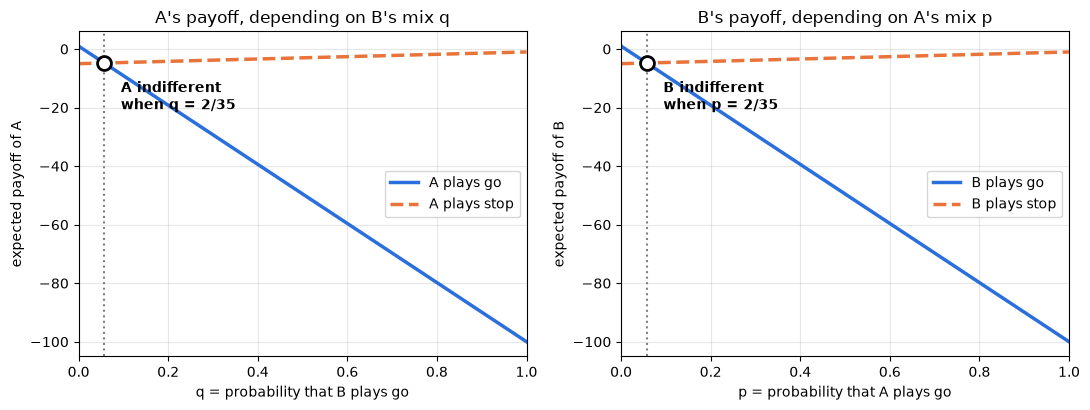

In [7]:
plot_indifference(game, acts, acts); plt.show()

**How to read the diagram.**

- **Left:** A's expected payoff for each of its two actions, depending on $q$ (how often B plays *go*).  
  On the left, when q=1,B chooses go, expected payoff of A when playing go is 0, when playing stop is -1...   
  Where the two lines cross, A is **indifferent**.
- **Right:** the same for B, depending on $p$ (how often A plays *go*).

In the mixed equilibrium, each player chooses the probability that puts the **other** player exactly on the crossing point:
B plays $q$ = the crossing value of the left panel, A plays $p$ = the crossing value of the right panel.

**Q3.** What do you conclude?

> **Solution.**   
> Accident ≈ 0.3%, but both stop ≈ 89% of the time: expected payoff −4.77, almost as bad as both stopping.   
> A shared rule (priority) is much better for autonomous vehicles.